# Lecture 2: Backpropagation and Training

## Week 8: From MLPs to CNNs

---

### What You'll Learn Today

1. **Loss Functions** - Measuring how wrong our predictions are
2. **Gradient Descent** - Finding the best weights
3. **Backpropagation** - Computing gradients efficiently
4. **Optimization Algorithms** - SGD, Adam, and more
5. **Training Loop** - Putting it all together

---

### The Big Picture

```
Training a Neural Network:

1. FORWARD PASS:  Input --> Network --> Prediction
2. COMPUTE LOSS:  Prediction vs Target --> Loss (error)
3. BACKWARD PASS: Compute gradients (how to change weights)
4. UPDATE:        Weights = Weights - learning_rate * gradients
5. REPEAT:        Until loss is small enough
```

Let's understand each step!

In [20]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

---

## Part 1: Loss Functions

### What is a Loss Function?

A **loss function** measures how wrong our predictions are:
- Lower loss = better predictions
- Our goal: minimize the loss by adjusting weights

```
Loss = f(predictions, targets)

Good predictions --> Low loss --> Happy!
Bad predictions  --> High loss --> Need to learn more
```

### Common Loss Functions

**1. Mean Squared Error (MSE)** - For Regression
```
MSE = (1/n) * sum((prediction - target)^2)
```

**2. Cross-Entropy Loss** - For Classification
```
CE = -sum(target * log(prediction))
```

**3. Binary Cross-Entropy** - For Binary Classification
```
BCE = -[y*log(p) + (1-y)*log(1-p)]
```

In [21]:
# Mean Squared Error - for regression

predictions = torch.tensor([2.5, 0.0, 2.0, 8.0])
targets = torch.tensor([3.0, -0.5, 2.0, 7.0])

# Manual calculation
mse_manual = torch.mean((predictions - targets) ** 2)
print(f"Manual MSE: {mse_manual.item():.4f}")

# Using PyTorch
mse_loss = nn.MSELoss()
mse_pytorch = mse_loss(predictions, targets)
print(f"PyTorch MSE: {mse_pytorch.item():.4f}")

Manual MSE: 0.3750
PyTorch MSE: 0.3750


In [22]:
# Cross-Entropy Loss - for multi-class classification

# Network outputs (raw logits for 3 classes)
logits = torch.tensor([[2.0, 1.0, 0.1],    # Sample 1: likely class 0
                       [0.5, 2.5, 0.3]])   # Sample 2: likely class 1

# True labels
targets = torch.tensor([0, 1])  # Sample 1 is class 0, Sample 2 is class 1

# PyTorch Cross-Entropy (includes softmax!)
ce_loss = nn.CrossEntropyLoss()
loss = ce_loss(logits, targets)
print(f"Cross-Entropy Loss: {loss.item():.4f}")

# What happens inside:
probs = torch.softmax(logits, dim=1)
print("\nProbabilities:")
print(probs)
print(f"\nSample 1: True=0, Predicted prob for class 0: {probs[0, 0]:.4f}")
print(f"Sample 2: True=1, Predicted prob for class 1: {probs[1, 1]:.4f}")

Cross-Entropy Loss: 0.3185

Probabilities:
tensor([[0.6590, 0.2424, 0.0986],
        [0.1086, 0.8025, 0.0889]])

Sample 1: True=0, Predicted prob for class 0: 0.6590
Sample 2: True=1, Predicted prob for class 1: 0.8025


### Visualizing Loss Functions

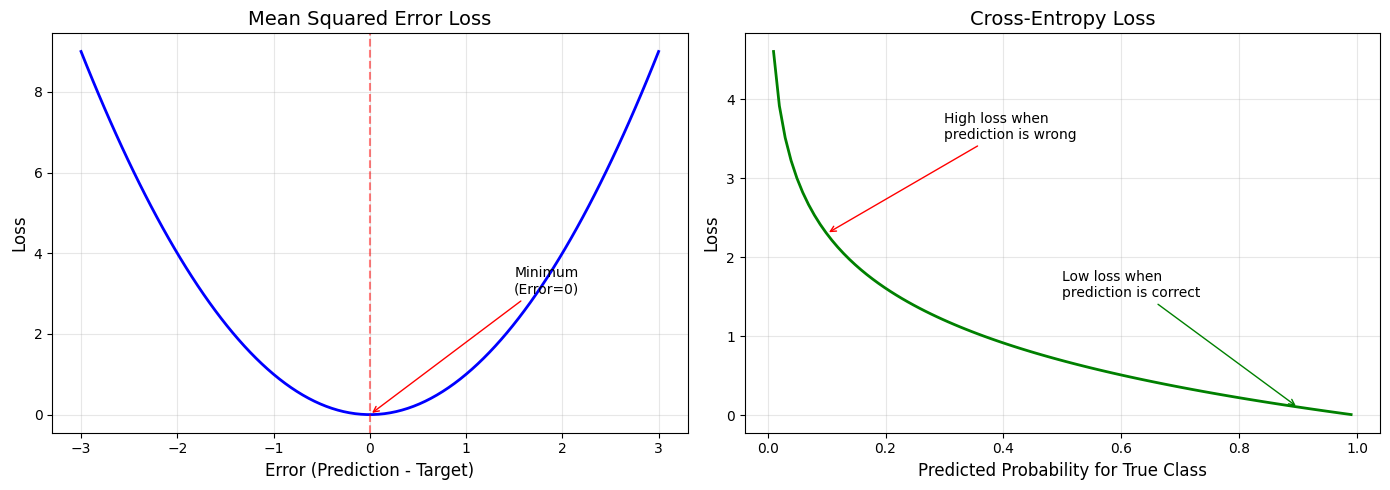

In [23]:
# Visualize MSE Loss
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MSE: Error vs Loss
errors = np.linspace(-3, 3, 100)
mse_values = errors ** 2

axes[0].plot(errors, mse_values, 'b-', linewidth=2)
axes[0].set_xlabel('Error (Prediction - Target)', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Mean Squared Error Loss', fontsize=14)
axes[0].axvline(x=0, color='r', linestyle='--', alpha=0.5)
axes[0].grid(True, alpha=0.3)
axes[0].annotate('Minimum\n(Error=0)', xy=(0, 0), xytext=(1.5, 3),
                 fontsize=10, arrowprops=dict(arrowstyle='->', color='red'))

# Cross-Entropy: Probability vs Loss
probs = np.linspace(0.01, 0.99, 100)
ce_values_true1 = -np.log(probs)  # True class = 1

axes[1].plot(probs, ce_values_true1, 'g-', linewidth=2)
axes[1].set_xlabel('Predicted Probability for True Class', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Cross-Entropy Loss', fontsize=14)
axes[1].grid(True, alpha=0.3)
axes[1].annotate('High loss when\nprediction is wrong', xy=(0.1, 2.3), xytext=(0.3, 3.5),
                 fontsize=10, arrowprops=dict(arrowstyle='->', color='red'))
axes[1].annotate('Low loss when\nprediction is correct', xy=(0.9, 0.1), xytext=(0.5, 1.5),
                 fontsize=10, arrowprops=dict(arrowstyle='->', color='green'))

plt.tight_layout()
plt.show()

---

## Part 2: Gradient Descent

### The Core Idea

**Gradient Descent** is how we find the weights that minimize the loss:

```
1. Start with random weights
2. Compute the loss
3. Compute gradients (direction of steepest increase)
4. Move weights in OPPOSITE direction (to decrease loss)
5. Repeat until loss is small

Update rule:
    weight_new = weight_old - learning_rate * gradient
```

### Visual Analogy

Imagine you're blindfolded on a hilly landscape, trying to find the lowest point:
- Feel the slope under your feet (gradient)
- Walk downhill (opposite of gradient)
- Take small steps (learning rate)
- Eventually reach the valley (minimum loss)

In [24]:
# Simple example: Find the minimum of f(x) = x^2

def f(x):
    """Function to minimize: f(x) = x^2"""
    return x ** 2

def gradient(x):
    """Gradient of f(x) = x^2 is f'(x) = 2x"""
    return 2 * x

# Gradient descent
x = 5.0  # Starting point
learning_rate = 0.1
history = [x]

print("Gradient Descent: Finding minimum of f(x) = x^2")
print(f"Starting at x = {x}, f(x) = {f(x)}")
print()

for i in range(10):
    grad = gradient(x)
    x = x - learning_rate * grad  # Update step
    history.append(x)
    print(f"Step {i+1}: x = {x:.4f}, f(x) = {f(x):.6f}, gradient = {grad:.4f}")

print(f"\nFinal: x = {x:.6f} (should be close to 0)")

Gradient Descent: Finding minimum of f(x) = x^2
Starting at x = 5.0, f(x) = 25.0

Step 1: x = 4.0000, f(x) = 16.000000, gradient = 10.0000
Step 2: x = 3.2000, f(x) = 10.240000, gradient = 8.0000
Step 3: x = 2.5600, f(x) = 6.553600, gradient = 6.4000
Step 4: x = 2.0480, f(x) = 4.194304, gradient = 5.1200
Step 5: x = 1.6384, f(x) = 2.684355, gradient = 4.0960
Step 6: x = 1.3107, f(x) = 1.717987, gradient = 3.2768
Step 7: x = 1.0486, f(x) = 1.099512, gradient = 2.6214
Step 8: x = 0.8389, f(x) = 0.703687, gradient = 2.0972
Step 9: x = 0.6711, f(x) = 0.450360, gradient = 1.6777
Step 10: x = 0.5369, f(x) = 0.288230, gradient = 1.3422

Final: x = 0.536871 (should be close to 0)


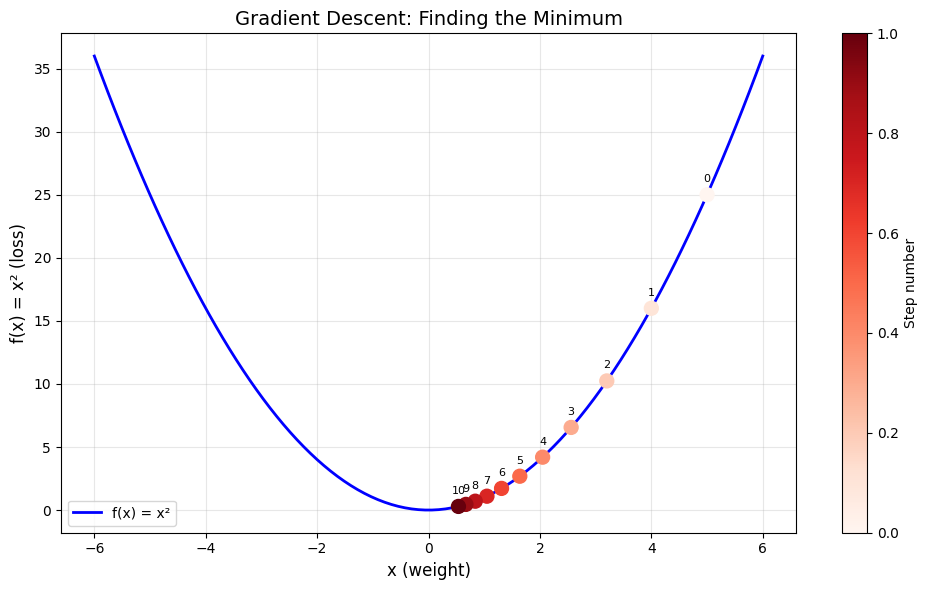

In [25]:
# Visualize gradient descent
x_range = np.linspace(-6, 6, 100)
y_range = x_range ** 2

plt.figure(figsize=(10, 6))
plt.plot(x_range, y_range, 'b-', linewidth=2, label='f(x) = x²')
plt.scatter(history, [h**2 for h in history], c=range(len(history)), 
            cmap='Reds', s=100, zorder=5)
for i, h in enumerate(history):
    plt.annotate(f'{i}', (h, h**2 + 1), fontsize=8, ha='center')

plt.xlabel('x (weight)', fontsize=12)
plt.ylabel('f(x) = x² (loss)', fontsize=12)
plt.title('Gradient Descent: Finding the Minimum', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.colorbar(plt.cm.ScalarMappable(cmap='Reds'), label='Step number', ax=plt.gca())
plt.tight_layout()
plt.show()

### Learning Rate: The Key Hyperparameter

```
Learning Rate too SMALL:         Learning Rate too LARGE:
- Very slow convergence          - May overshoot minimum
- Many steps needed              - May oscillate or diverge
- Safe but inefficient           - Fast but unstable

Learning Rate just RIGHT:
- Fast convergence
- Stable optimization
- This is what we want!
```

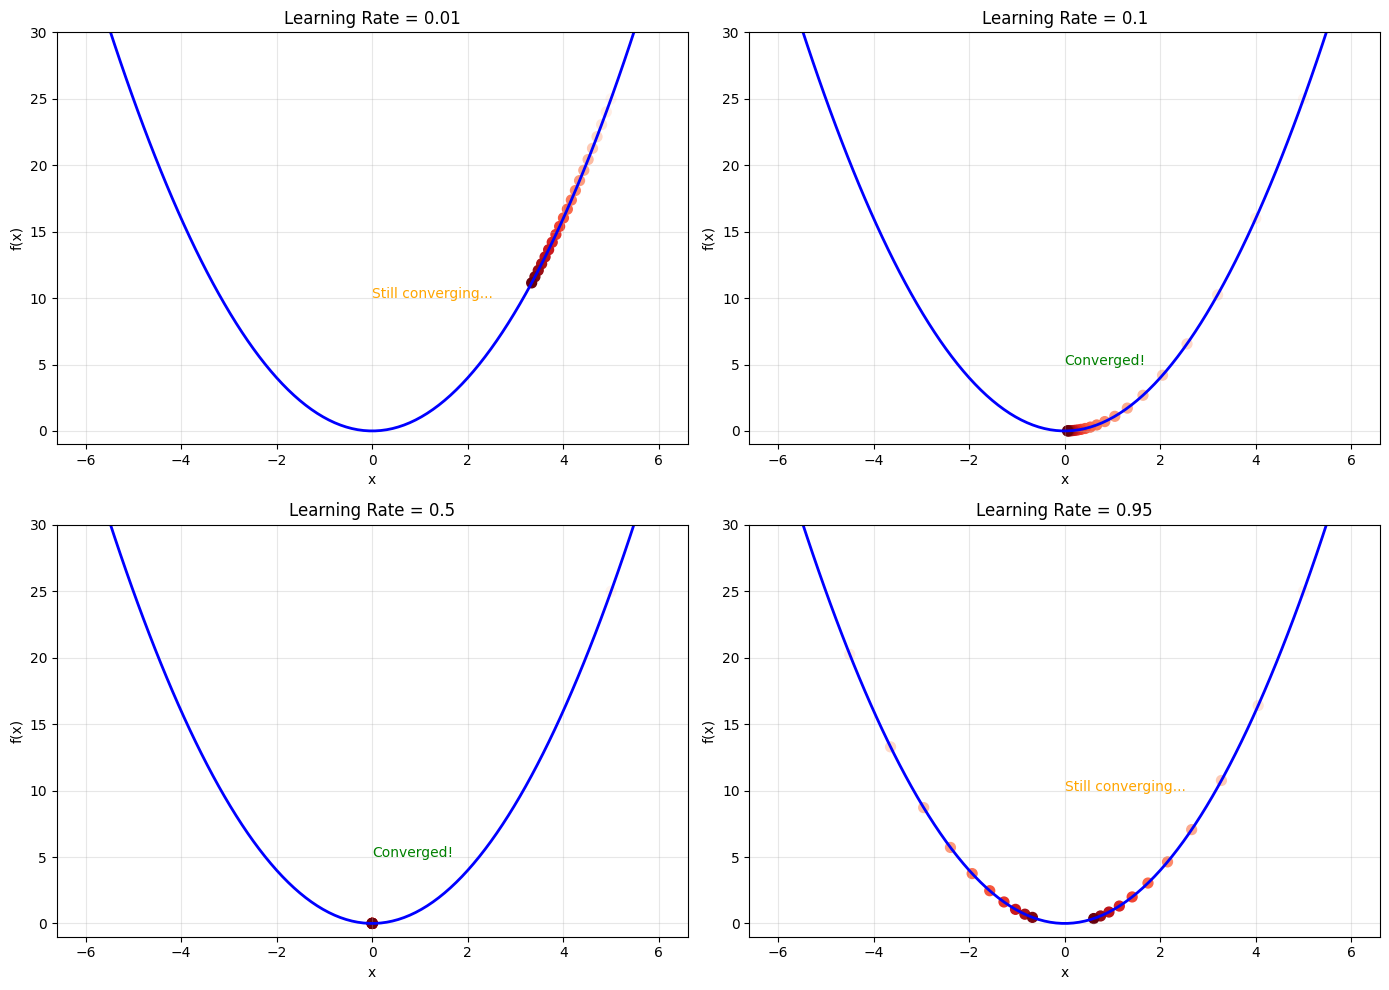

In [26]:
# Comparing different learning rates

def run_gradient_descent(start, lr, steps=20):
    x = start
    history = [x]
    for _ in range(steps):
        x = x - lr * 2 * x
        history.append(x)
    return history

learning_rates = [0.01, 0.1, 0.5, 0.95]
start = 5.0

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

x_range = np.linspace(-6, 6, 100)

for ax, lr in zip(axes, learning_rates):
    history = run_gradient_descent(start, lr)
    
    ax.plot(x_range, x_range**2, 'b-', linewidth=2)
    ax.scatter(history, [h**2 for h in history], c=range(len(history)), 
               cmap='Reds', s=50)
    ax.set_xlabel('x')
    ax.set_ylabel('f(x)')
    ax.set_title(f'Learning Rate = {lr}', fontsize=12)
    ax.set_ylim(-1, 30)
    ax.grid(True, alpha=0.3)
    
    # Add annotation
    final_x = history[-1]
    if abs(final_x) < 0.1:
        ax.annotate('Converged!', xy=(0, 5), fontsize=10, color='green')
    elif abs(final_x) > 5:
        ax.annotate('Diverged!', xy=(0, 15), fontsize=10, color='red')
    else:
        ax.annotate('Still converging...', xy=(0, 10), fontsize=10, color='orange')

plt.tight_layout()
plt.show()

---

## Part 3: Backpropagation

### The Challenge

In a neural network, we have **many weights across multiple layers**:
- How do we compute the gradient for each weight?
- The answer: **Backpropagation** (using the chain rule)

### The Chain Rule

If `y = f(g(x))`, then:
```
dy/dx = dy/dg * dg/dx
```

### Backpropagation in Neural Networks

```
FORWARD PASS:
Input --> Layer 1 --> Layer 2 --> Output --> Loss
  x   -->   h1    -->   h2    -->   y    -->  L

BACKWARD PASS (using chain rule):
dL/dW2 = dL/dy * dy/dW2         (output layer gradient)
dL/dW1 = dL/dy * dy/dh2 * dh2/dW1  (hidden layer gradient)

We compute gradients from output to input (hence "back" propagation)
```

In [27]:
# PyTorch handles backpropagation automatically!
# We just need to call .backward()

# Example: Simple computation with gradients
x = torch.tensor(2.0, requires_grad=True)  # Tell PyTorch to track gradients
y = x ** 2  # y = x^2
z = 3 * y + 1  # z = 3*x^2 + 1

print(f"x = {x.item()}")
print(f"y = x² = {y.item()}")
print(f"z = 3y + 1 = {z.item()}")
print()

# Compute gradients: dz/dx
z.backward()

print(f"Gradient dz/dx = {x.grad.item()}")
print(f"Manual: dz/dx = d(3x²+1)/dx = 6x = 6*2 = 12 ✓")

x = 2.0
y = x² = 4.0
z = 3y + 1 = 13.0

Gradient dz/dx = 12.0
Manual: dz/dx = d(3x²+1)/dx = 6x = 6*2 = 12 ✓


In [28]:
# Backpropagation in a neural network

# Create a simple network
model = nn.Sequential(
    nn.Linear(2, 3),
    nn.ReLU(),
    nn.Linear(3, 1)
)

# Input and target
x = torch.tensor([[1.0, 2.0]])
target = torch.tensor([[5.0]])

# Forward pass
output = model(x)
print(f"Input: {x.tolist()}")
print(f"Output: {output.item():.4f}")
print(f"Target: {target.item()}")

# Compute loss
loss = nn.MSELoss()(output, target)
print(f"\nLoss: {loss.item():.4f}")

# Backward pass - compute ALL gradients
loss.backward()

# Now each parameter has a .grad attribute!
print("\nGradients after backpropagation:")
for name, param in model.named_parameters():
    print(f"  {name}: grad shape = {param.grad.shape}")

Input: [[1.0, 2.0]]
Output: 0.7049
Target: 5.0

Loss: 18.4483

Gradients after backpropagation:
  0.weight: grad shape = torch.Size([3, 2])
  0.bias: grad shape = torch.Size([3])
  2.weight: grad shape = torch.Size([1, 3])
  2.bias: grad shape = torch.Size([1])


### Visualizing the Computational Graph

In [29]:
# Simple example to see the flow

print("Computational Graph:")
print("""
FORWARD PASS (compute values):         BACKWARD PASS (compute gradients):

    x = 2.0                                dL/dx = dL/dy * dy/dx
      |                                          = dL/dy * 2x
      v                                          = 2.0 * 2*2 = 8.0
    y = x²  = 4.0                               ^
      |                                         |
      v                                    dL/dy = 2*(y - target)
    L = (y - target)² = (4 - 3)² = 1           = 2*(4 - 3) = 2.0
    
    (target = 3.0)
""")

# Verify with PyTorch
x = torch.tensor(2.0, requires_grad=True)
target = torch.tensor(3.0)

y = x ** 2
loss = (y - target) ** 2

loss.backward()

print(f"PyTorch computed gradient dL/dx = {x.grad.item()}")
print(f"Manual calculation: 2 * (x² - target) * 2x = 2 * (4-3) * 4 = 8.0 ✓")

Computational Graph:

FORWARD PASS (compute values):         BACKWARD PASS (compute gradients):

    x = 2.0                                dL/dx = dL/dy * dy/dx
      |                                          = dL/dy * 2x
      v                                          = 2.0 * 2*2 = 8.0
    y = x²  = 4.0                               ^
      |                                         |
      v                                    dL/dy = 2*(y - target)
    L = (y - target)² = (4 - 3)² = 1           = 2*(4 - 3) = 2.0

    (target = 3.0)

PyTorch computed gradient dL/dx = 8.0
Manual calculation: 2 * (x² - target) * 2x = 2 * (4-3) * 4 = 8.0 ✓


---

## Part 4: Optimization Algorithms

### Beyond Basic Gradient Descent

```
1. SGD (Stochastic Gradient Descent)
   - Use mini-batches instead of full dataset
   - Faster but noisier updates
   - weight = weight - lr * gradient

2. SGD with Momentum
   - Accumulate velocity to overcome local minima
   - velocity = momentum * velocity + gradient
   - weight = weight - lr * velocity

3. Adam (Adaptive Moment Estimation) - MOST POPULAR!
   - Combines momentum + adaptive learning rates
   - Works well out of the box
   - Default choice for most problems
```

In [30]:
import torch.optim as optim

# Create a simple model
model = nn.Linear(10, 1)

# Different optimizers
optimizer_sgd = optim.SGD(model.parameters(), lr=0.01)
optimizer_sgd_momentum = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
optimizer_adam = optim.Adam(model.parameters(), lr=0.001)

print("Available optimizers in PyTorch:")
print("- SGD: Simple, requires tuning")
print("- SGD + Momentum: Better for deep networks")
print("- Adam: Adaptive, works well by default (recommended!)")
print("- RMSprop: Good for RNNs")
print("- AdamW: Adam with weight decay (regularization)")

Available optimizers in PyTorch:
- SGD: Simple, requires tuning
- SGD + Momentum: Better for deep networks
- Adam: Adaptive, works well by default (recommended!)
- RMSprop: Good for RNNs
- AdamW: Adam with weight decay (regularization)


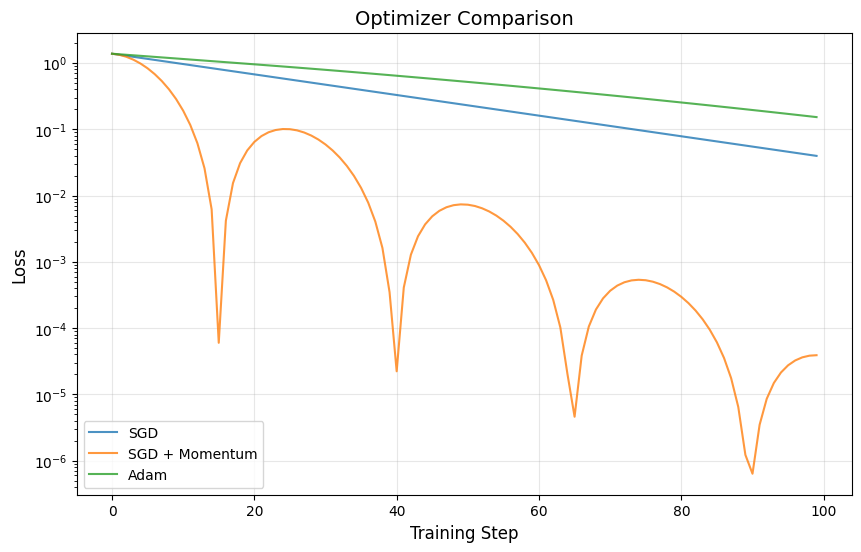


Learned parameters (true: w=2, b=1):
  Weight: 1.5911
  Bias: 0.9961


In [31]:
# Compare optimizers on a simple problem

def train_simple_model(optimizer_class, lr, steps=100, **kwargs):
    """Train a model to fit y = 2*x + 1"""
    torch.manual_seed(42)
    model = nn.Linear(1, 1)
    optimizer = optimizer_class(model.parameters(), lr=lr, **kwargs)
    loss_fn = nn.MSELoss()
    
    # Training data: y = 2x + 1
    X = torch.randn(100, 1)
    y = 2 * X + 1
    
    losses = []
    for _ in range(steps):
        pred = model(X)
        loss = loss_fn(pred, y)
        losses.append(loss.item())
        
        optimizer.zero_grad()  # Clear old gradients
        loss.backward()        # Compute gradients
        optimizer.step()       # Update weights
    
    return losses, model

# Train with different optimizers
losses_sgd, _ = train_simple_model(optim.SGD, lr=0.01)
losses_momentum, _ = train_simple_model(optim.SGD, lr=0.01, momentum=0.9)
losses_adam, model = train_simple_model(optim.Adam, lr=0.01)

# Plot comparison
plt.figure(figsize=(10, 6))
plt.plot(losses_sgd, label='SGD', alpha=0.8)
plt.plot(losses_momentum, label='SGD + Momentum', alpha=0.8)
plt.plot(losses_adam, label='Adam', alpha=0.8)
plt.xlabel('Training Step', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Optimizer Comparison', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

print(f"\nLearned parameters (true: w=2, b=1):")
print(f"  Weight: {model.weight.item():.4f}")
print(f"  Bias: {model.bias.item():.4f}")

---

## Part 5: The Complete Training Loop

Now let's put everything together into a complete training loop!

In [32]:
# Complete training example: Classify XOR problem

# XOR data (non-linearly separable!)
X = torch.tensor([[0.0, 0.0],
                  [0.0, 1.0],
                  [1.0, 0.0],
                  [1.0, 1.0]])

y = torch.tensor([[0.0],   # 0 XOR 0 = 0
                  [1.0],   # 0 XOR 1 = 1
                  [1.0],   # 1 XOR 0 = 1
                  [0.0]])  # 1 XOR 1 = 0

print("XOR Problem:")
print("Input 1 | Input 2 | Output")
for i in range(4):
    print(f"   {int(X[i,0])}   |    {int(X[i,1])}    |   {int(y[i])}")

XOR Problem:
Input 1 | Input 2 | Output
   0   |    0    |   0
   0   |    1    |   1
   1   |    0    |   1
   1   |    1    |   0


In [33]:
# Build the network
model = nn.Sequential(
    nn.Linear(2, 4),     # 2 inputs -> 4 hidden neurons
    nn.ReLU(),           # Activation
    nn.Linear(4, 1),     # 4 hidden -> 1 output
    nn.Sigmoid()         # Output between 0 and 1
)

# Loss function and optimizer
loss_fn = nn.BCELoss()  # Binary Cross-Entropy
optimizer = optim.Adam(model.parameters(), lr=0.1)

print("Model Architecture:")
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters())}")

Model Architecture:
Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=1, bias=True)
  (3): Sigmoid()
)

Total parameters: 17


In [34]:
# Training loop

epochs = 1000
losses = []

print("Training...")
for epoch in range(epochs):
    # Forward pass
    predictions = model(X)
    loss = loss_fn(predictions, y)
    
    # Backward pass
    optimizer.zero_grad()  # Clear old gradients
    loss.backward()        # Compute gradients
    optimizer.step()       # Update weights
    
    losses.append(loss.item())
    
    # Print progress
    if (epoch + 1) % 200 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

print("\nTraining complete!")

Training...
Epoch 200/1000, Loss: 0.4779
Epoch 400/1000, Loss: 0.4774
Epoch 600/1000, Loss: 0.4775
Epoch 800/1000, Loss: 0.4774
Epoch 1000/1000, Loss: 0.4774

Training complete!


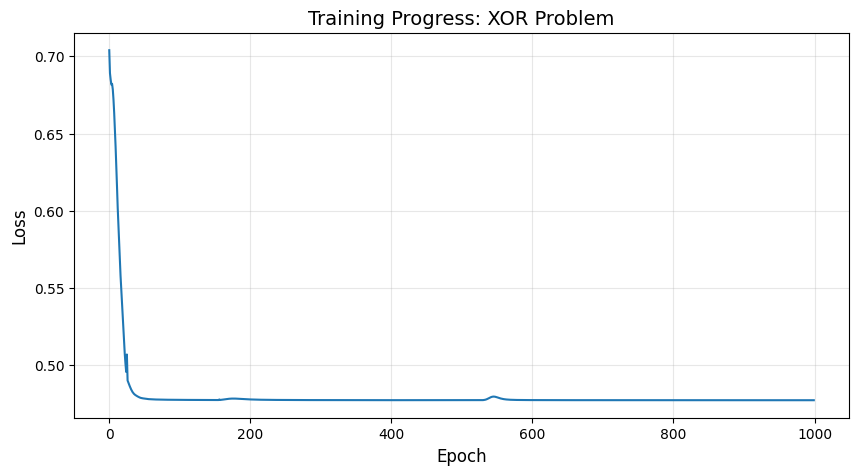

In [35]:
# Plot training progress
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training Progress: XOR Problem', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

In [36]:
# Test the trained model
with torch.no_grad():  # No need to track gradients for inference
    predictions = model(X)
    predicted_classes = (predictions > 0.5).float()

print("Results after training:")
print("")
print("Input 1 | Input 2 | True | Predicted | Confidence")
print("-" * 55)
for i in range(4):
    print(f"   {int(X[i,0])}   |    {int(X[i,1])}    |  {int(y[i])}   |     {int(predicted_classes[i])}     |   {predictions[i].item():.4f}")

accuracy = (predicted_classes == y).float().mean()
print(f"\nAccuracy: {accuracy.item():.1%}")

Results after training:

Input 1 | Input 2 | True | Predicted | Confidence
-------------------------------------------------------
   0   |    0    |  0   |     0     |   0.0000
   0   |    1    |  1   |     1     |   0.6667
   1   |    0    |  1   |     1     |   0.6667
   1   |    1    |  0   |     1     |   0.6667

Accuracy: 75.0%


---

## Summary

### The Training Process:

```python
for epoch in range(num_epochs):
    # 1. Forward pass
    predictions = model(inputs)
    loss = loss_fn(predictions, targets)
    
    # 2. Backward pass
    optimizer.zero_grad()  # Clear old gradients
    loss.backward()        # Compute gradients
    optimizer.step()       # Update weights
```

### Key Concepts:

1. **Loss Functions** measure prediction error
   - MSE for regression
   - Cross-Entropy for classification

2. **Gradient Descent** finds optimal weights by following gradients downhill

3. **Backpropagation** efficiently computes all gradients using the chain rule

4. **Optimizers** implement gradient descent variants
   - **Adam** is the default choice!

5. **Learning Rate** is crucial - start with 0.001 for Adam

### Next Lecture:
We'll learn about **MLPs** and how to **prevent overfitting**!

---

## Exercises

1. Change the learning rate in the XOR example and observe the effect
2. Try different optimizers (SGD, RMSprop) and compare convergence
3. Add more hidden neurons - does it train faster?